# Business Use Case 

The ability to classify whether a person is walking or running has significant business value across multiple industries. Companies use such predictive models to enhance user experience, monitor health conditions, and build intelligent systems. With the rise of wearable technology and fitness applications, activity recognition has become a core feature in many consumer products.

This project demonstrates how raw sensor data can be transformed into actionable insights, allowing organizations to deliver personalized services and improve operational efficiency.

# Domain Analysis

The project belongs to the domain of Human Activity Recognition (HAR), which is an important application of Machine Learning and Data Science. HAR focuses on identifying human physical activities such as walking, running, sitting, or standing using data collected from sensors like accelerometers and gyroscopes. With the rapid growth of Internet of Things and wearable devices, HAR systems have become a key component in modern smart technologies.

The dataset used in this project contains motion sensor readings captured over time, making it a form of time-series data. Each observation represents the physical movement of a person in three-dimensional space using acceleration and angular velocity. Although the time component exists, the problem is treated as a classification task rather than sequence modeling.

In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv("walkrun.csv")

In [3]:
df

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...,...,...,...
88583,2017-7-9,20:9:15:317911028,viktor,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,2017-7-9,20:9:15:517889022,viktor,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,2017-7-9,20:9:15:717828989,viktor,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,2017-7-9,20:9:15:917932987,viktor,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [5]:
df.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


In [6]:
df.isnull().sum()

date              0
time              0
username          0
wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64

In [7]:
df["activity"].unique()

array([0, 1], dtype=int64)

In [8]:
df["activity"].value_counts()

activity
1    44365
0    44223
Name: count, dtype: int64

# so here the data is balanced, So we do not need for balancing like applying smote or any other


In [9]:
df=df.drop(['date', 'time', 'username'], axis=1)

In [10]:
df

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...
88583,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


# eda

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

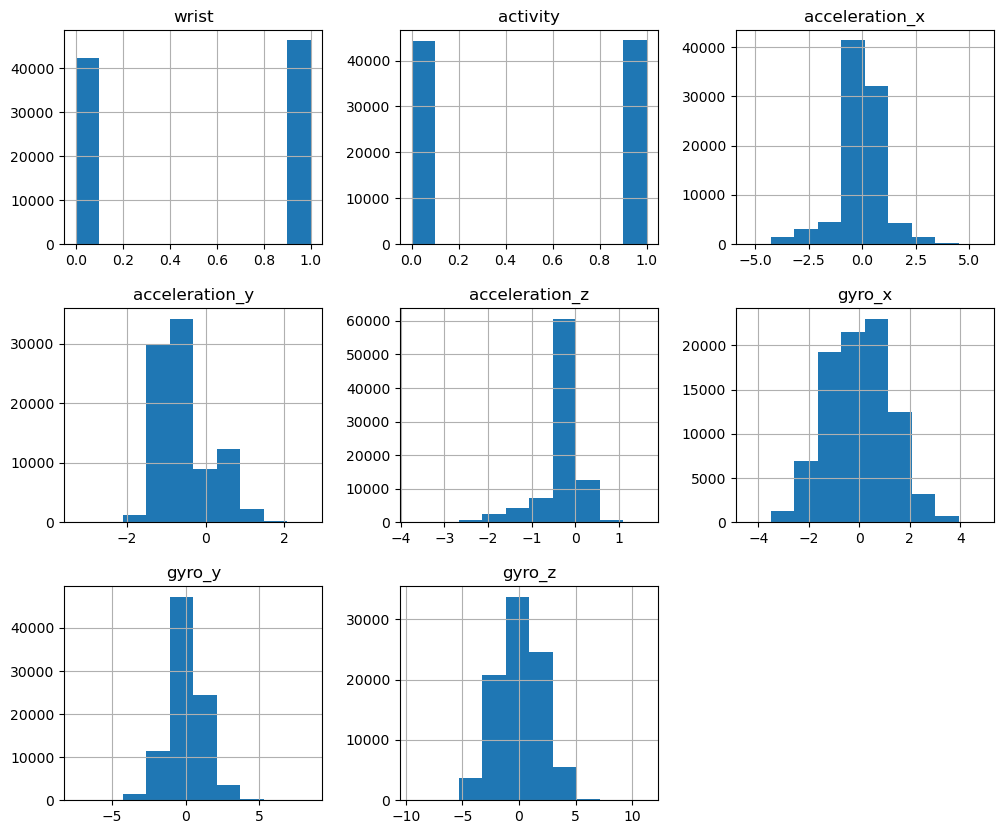

In [12]:
df.hist(figsize=(12,8))
plt.show()

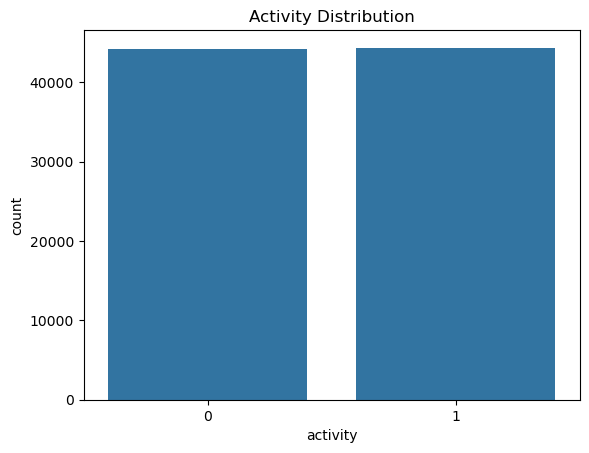

In [13]:
sns.countplot(x="activity", data=df)
plt.title("Activity Distribution")
plt.show()

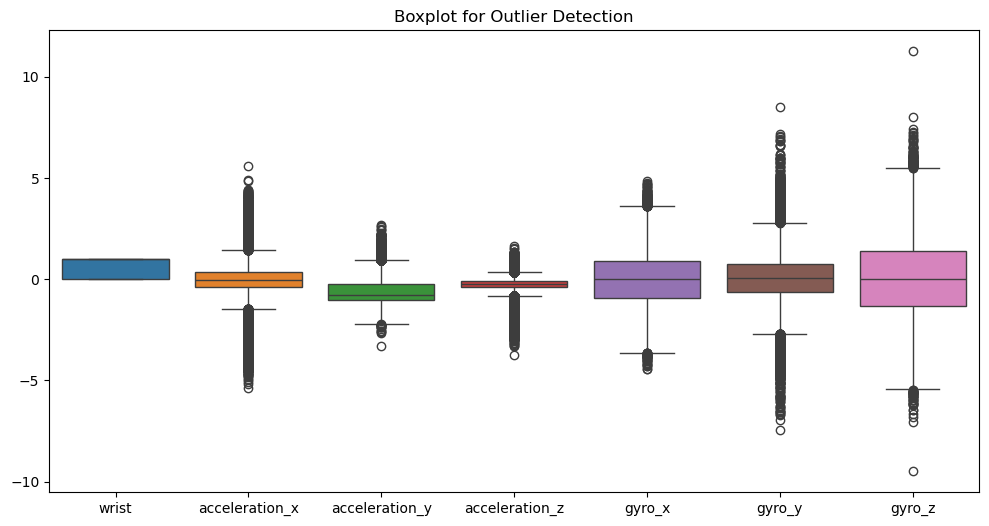

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("activity", axis=1))
plt.title("Boxplot for Outlier Detection")
plt.show()

so there are outliers in the follwoing acceleration_x	acceleration_y	acceleration_z	gyro_x	gyro_y	gyro_z

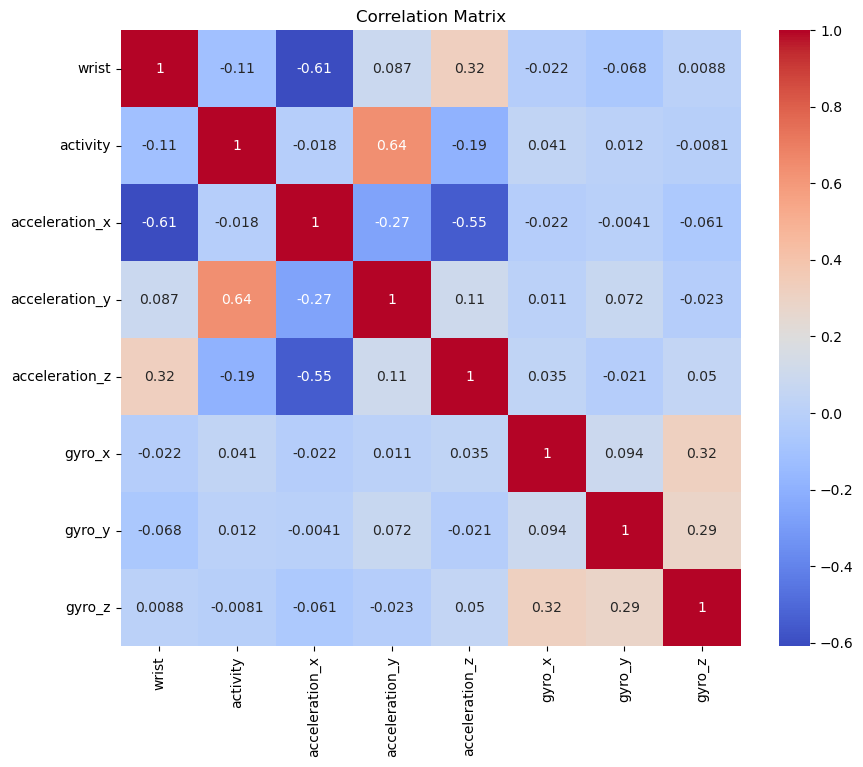

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

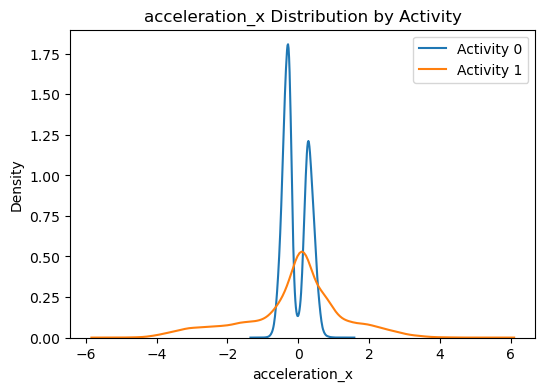

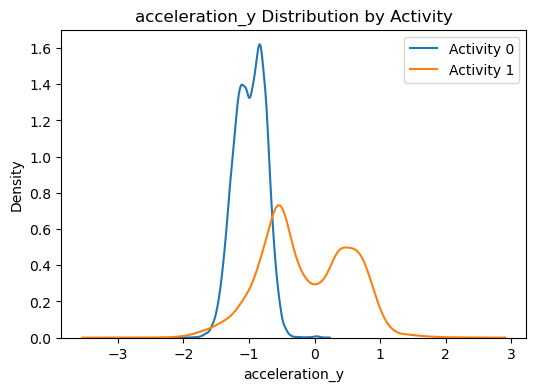

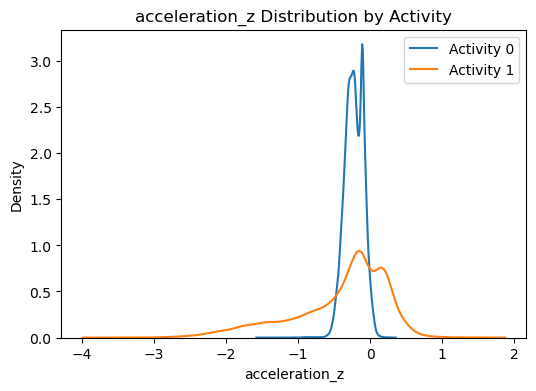

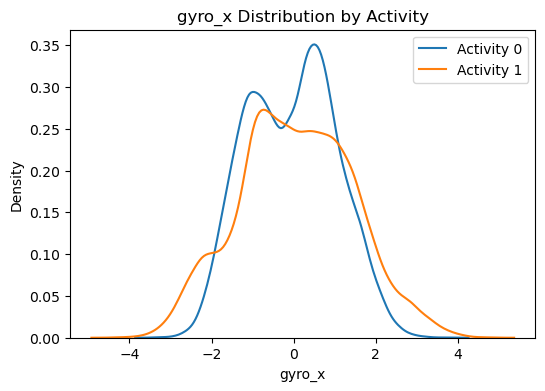

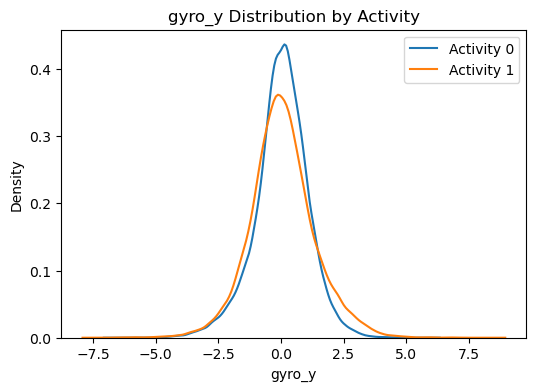

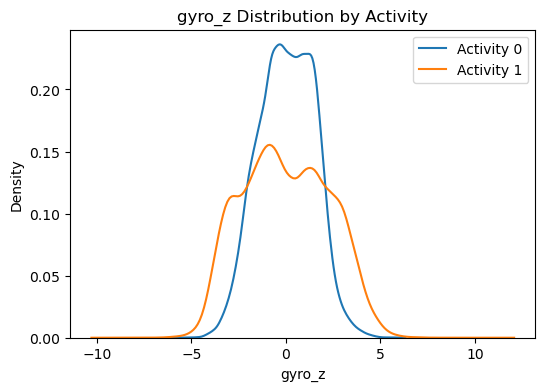

In [16]:

features = ["acceleration_x", "acceleration_y", "acceleration_z", "gyro_x", "gyro_y", "gyro_z"]
for col in features:
    plt.figure(figsize=(6,4))
    for act in df["activity"].unique():
        sns.kdeplot(df[df["activity"]==act][col], label=f"Activity {act}")
    
    plt.title(f"{col} Distribution by Activity")
    plt.legend()
    plt.show()

# removing the outliers

In [17]:


for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]



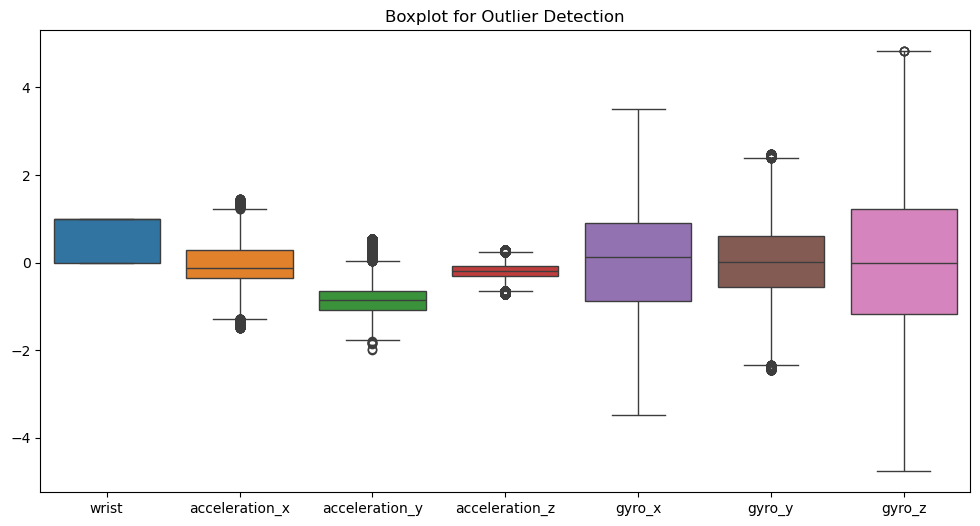

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("activity", axis=1))
plt.title("Boxplot for Outlier Detection")
plt.show()

so almost outliers are removed  but there is still outliers there which need to be taken care of

In [19]:
X = df.drop('activity', axis=1)
y = df['activity']

# train_test_split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit ONLY on train
X_test = scaler.transform(X_test)         # transform test using same scaler

# LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

In [23]:
y_pred1=lr.predict(X_test)

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      8471
           1       0.91      0.78      0.84      3383

    accuracy                           0.92     11854
   macro avg       0.92      0.88      0.89     11854
weighted avg       0.92      0.92      0.92     11854



# RandomForestClassifier

In [25]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [26]:
y_pred2=rf.predict(X_test)

In [27]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8471
           1       0.98      0.98      0.98      3383

    accuracy                           0.99     11854
   macro avg       0.99      0.99      0.99     11854
weighted avg       0.99      0.99      0.99     11854



In [28]:
!pip install tensorflow

# Sequential

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=32)

C:\Users\shahh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9169 - loss: 0.1944
Epoch 2/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9826 - loss: 0.0539
Epoch 3/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0435
Epoch 4/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9868 - loss: 0.0387
Epoch 5/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9878 - loss: 0.0358
Epoch 6/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9886 - loss: 0.0335
Epoch 7/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9889 - loss: 0.0324
Epoch 8/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9892 - loss: 0.0314
Epoch 9/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9895 - loss: 0.0310
Epoch 10/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9892 - loss: 0.0301


In [30]:
y_pred = model.predict(X_test)

371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
y_pred_classes = (y_pred > 0.5).astype(int)

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8471
           1       0.98      0.98      0.98      3383

    accuracy                           0.99     11854
   macro avg       0.99      0.99      0.99     11854
weighted avg       0.99      0.99      0.99     11854



In [33]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_classes))

[[8407   64]
 [  72 3311]]


In [34]:
df

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...
88583,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


In [35]:
y_train_pred = model.predict(X_train)

# Convert to 0/1 using threshold
y_train_pred = (y_train_pred > 0.5).astype(int)

1482/1482 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [36]:
print("TRAIN PERFORMANCE:")
print(classification_report(y_train, y_train_pred))

TRAIN PERFORMANCE:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     34185
           1       0.98      0.98      0.98     13229

    accuracy                           0.99     47414
   macro avg       0.99      0.99      0.99     47414
weighted avg       0.99      0.99      0.99     47414



In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# Logistic Regression
y_pred_lr = lr.predict(X_test)
results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
])

# Random Forest
y_pred_rf = rf.predict(X_test)
results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
])

# ANN
y_pred_ann = (model.predict(X_test) > 0.5).astype("int32")
results.append([
    "ANN",
    accuracy_score(y_test, y_pred_ann),
    precision_score(y_test, y_pred_ann),
    recall_score(y_test, y_pred_ann),
    f1_score(y_test, y_pred_ann)
])

371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [38]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.917159,0.912969,0.784511,0.843879
1,Random Forest,0.988611,0.982472,0.977535,0.979997
2,ANN,0.988527,0.981037,0.978717,0.979876


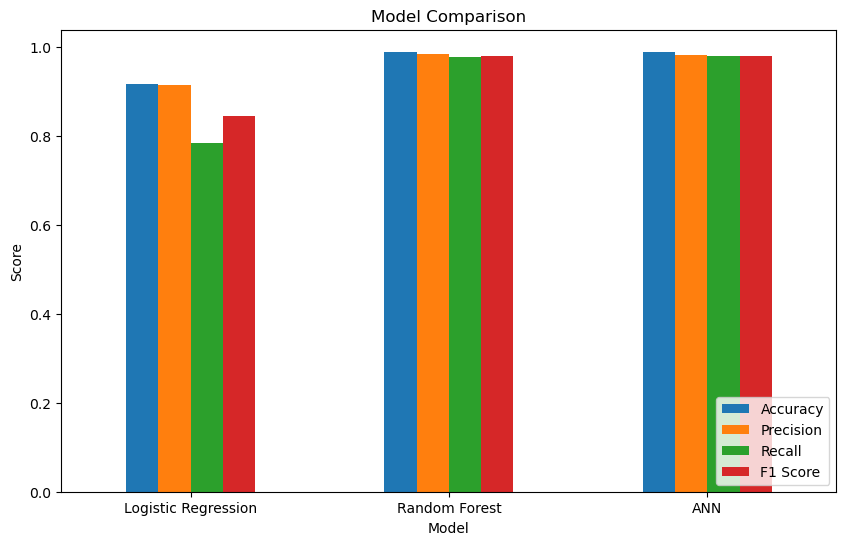

In [39]:
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot()
    plt.title(title)
    plt.show()

In [41]:
from sklearn.metrics import roc_curve, auc

# Get probabilities
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_ann = model.predict(X_test)

# ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

# AUC scores
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_ann = auc(fpr_ann, tpr_ann)

371/371 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


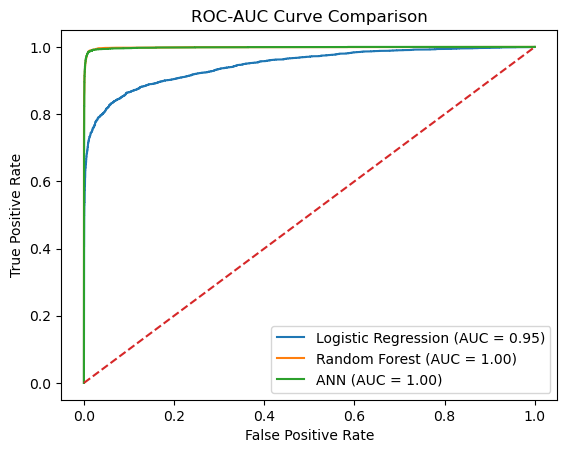

In [42]:
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {auc_ann:.2f})")

plt.plot([0,1], [0,1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.show()

# Model Comparison Report
In this project, multiple machine learning models were developed and evaluated to classify whether a person is walking or
 running based on motion sensor data. The models were compared using various performance metrics such as accuracy, precision, 
 recall, F1-score, confusion matrix, and ROC-AUC curve to determine the most suitable model for deployment..

### Models Implemented

The following models were trained and tested:

* Logistic Regression
* Random Forest Classifier
* Artificial Neural Network (ANN)

### Evaluation Metrics Used
To ensure a fair and comprehensive comparison, the following metrics were used:
* Accuracy: Measures overall correctness of the model
* Precision: Measures how many predicted positives are actually correct
* Recall: Measures how many actual positives are correctly identified
* F1-Score: Harmonic mean of precision and recall
* Confusion Matrix: Shows classification errors
* ROC-AUC Curve: Measures model’s ability to distinguish between classes

### Final Model Selection
-> Selected Model: <B> "Random Forest"

Random Forest is selected as the best model for the following reasons:

* Provides high accuracy with consistent performance
* Handles non-linear relationships effectively
* Less prone to overfitting compared to ANN
* Requires minimal hyperparameter tuning
* Performs well on real-world noisy sensor data
* Easier to deploy compared to deep learning models


| Model               | Accuracy  | Stability | Overfitting Risk | Complexity | Suitability |
| ------------------- | --------- | --------- | ---------------- | ---------- | ----------- |
| Logistic Regression | Medium    | High      | Low              | Low        | Baseline    |
| Random Forest       | High      | High      | Low              | Medium     | Best        |
| ANN                 | Very High | Medium    | High             | High       | Advanced    |


## Challenges Faced Report
#### Irrelevant Features
* Columns like date, time, username were not useful<br>
  -> removed to reduce noise and improve model performance
#### Data Scaling Issue
* Sensor values had different ranges<br>
  -> Applied StandardScaler for normalization
#### Outliers in Data
* Extreme values present in acceleration and gyroscope
-> Removed using IQR method
#### Model Overfitting (ANN)
* ANN showed very high accuracy (overfitting risk)<br>
-> Used validation split and limited epochs
#### Feature Correlation
* Some features were highly correlated<br>
-> Analyzed using heatmap
#### Model Selection Difficulty
* Multiple models performed well<br>
-> Compared using accuracy, F1-score, ROC-AUC
#### Understanding Sensor Data
* Raw sensor values were difficult to interpret<br>
-> Performed EDA and visualization
#### Class Balance Check
* Needed to ensure balanced dataset<br>
-> Verified using countplot

# Final Conclusion

* The project successfully classified human activity (walking vs running) using sensor data.
* Acceleration and gyroscope features proved to be highly important for prediction.
* Proper data preprocessing (removing irrelevant features, scaling, outlier handling) significantly improved model performance.
* Multiple models were applied:
  * Logistic Regression → baseline performance
  * Random Forest → best balance
  * ANN → highest accuracy but overfitting risk
* Random Forest was selected as the final model because:
  * High accuracy and stability
  * Handles non-linear data well
  * Less overfitting compared to ANN
  * Requires minimal tuning
* The model is suitable for real-world applications such as:
  * Fitness tracking systems
  * Wearable devices
  * Healthcare monitoring
* Overall, the project demonstrates an effective end-to-end machine learning pipeline from data analysis to model selection.